In [ ]:
!ls


'kaggle (1).json'   sample_data


In [ ]:
!mkdir -p ~/.kaggle
!cp 'kaggle (1).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lava18/google-play-store-apps

Dataset URL: https://www.kaggle.com/datasets/lava18/google-play-store-apps
License(s): CC-BY-SA-4.0
  0% 0.00/1.94M [00:00<?, ?B/s]
100% 1.94M/1.94M [00:00<00:00, 736MB/s]


In [ ]:
!unzip google-play-store-apps.zip

Archive:  google-play-store-apps.zip
  inflating: googleplaystore.csv     
  inflating: googleplaystore_user_reviews.csv  
  inflating: license.txt             


In [ ]:
import pandas as pd

df = pd.read_csv("googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
import numpy as np

data = df.copy()

# Remove rows with missing Rating
data = data[data['Rating'].notna()]

# ---- CLEAN INSTALLS ----
data['Installs'] = (
    data['Installs']
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

# Remove any non-numeric values (safe)
data['Installs'] = pd.to_numeric(data['Installs'], errors='coerce')
data['Installs'] = data['Installs'].fillna(0).astype(int)

# ---- CLEAN REVIEWS ----
data['Reviews'] = pd.to_numeric(data['Reviews'], errors='coerce').fillna(0)

# ---- CLEAN PRICE ----
data['Price'] = (
    data['Price']
    .astype(str)
    .str.replace("$", "", regex=False)
)

# Convert price to numeric (Free → 0)
data['Price'] = pd.to_numeric(data['Price'], errors='coerce').fillna(0)

# ---- CLEAN SIZE ----
def convert_size(x):
    x = str(x)
    if "Varies" in x:
        return np.nan
    if "k" in x.lower():
        return float(x[:-1]) / 1024  # KB to MB
    if "M" in x:
        return float(x[:-1])
    return np.nan

data['Size'] = data['Size'].apply(convert_size)
data['Size'] = data['Size'].fillna(data['Size'].median())

data.head()



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
import numpy as np

# Step 1: Compute weighted score
df['Fake_Score'] = 0
df.loc[df['Rating'] < 3.5, 'Fake_Score'] += 2
df.loc[df['Reviews'] < 200, 'Fake_Score'] += 1
df.loc[df['Installs'] < 5000, 'Fake_Score'] += 1
df.loc[df['Days_Since_Update'] > 365, 'Fake_Score'] += 1
df.loc[(df['Price'] > 5) & (df['Size'] < 10), 'Fake_Score'] += 1

# Step 2: Deterministic Fake label
df['Fake'] = np.where(df['Fake_Score'] >= 3, 1, 0)

# Step 3: Introduce small random flips (~2–3% of data)
flip_idx = np.random.choice(df.index, size=int(0.02*len(df)), replace=False)
df.loc[flip_idx, 'Fake'] = 1 - df.loc[flip_idx, 'Fake']


In [ ]:
features = ["Rating", "Reviews", "Installs", "Price", "Size"]
X = data[features]
y = data["Fake"]

X.head()


,Rating,Reviews,Installs,Price,Size
0,4.1,159.0,10000,0.0,19.0
1,3.9,967.0,500000,0.0,14.0
2,4.7,87510.0,5000000,0.0,8.7
3,4.5,215644.0,50000000,0.0,25.0
4,4.3,967.0,100000,0.0,2.8


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((7493, 5), (1874, 5))

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


feature_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price',
                'Type_enc', 'Category_enc', 'Content_Rating_enc',
                'Genres_enc', 'Days_Since_Update']

X = df[feature_cols]
y = df['Fake']  # new target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9732595666205625
Confusion Matrix:
 [[1418   27]
 [  31  693]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Classical ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Features & target ---
feature_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price',
                'Type_enc', 'Category_enc', 'Content_Rating_enc',
                'Genres_enc', 'Days_Since_Update']

X = df[feature_cols]
y = df['Fake']  # target column

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Handle missing values ---
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# --- Optional: scale features for models that benefit ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Initialize models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=1, reg_lambda=1, random_state=42
    )
}

# --- Train, predict, and collect metrics ---
results = []

for name, model in models.items():
    # Use scaled features for LR, SVM, KNN
    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Precision (%)": round(prec*100,2),
        "Recall (%)": round(rec*100,2),
        "F1 (%)": round(f1*100,2),
        "Accuracy (%)": round(acc*100,2)
    })

# --- Display results table ---
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print(results_df)


                     Precision (%)  Recall (%)  F1 (%)  Accuracy (%)
Model                                                               
Logistic Regression          87.00       50.83   64.17         81.05
SVM                          89.95       51.93   65.85         82.02
Naive Bayes                  36.25       99.59   53.15         41.40
KNN                          79.21       66.85   72.51         83.08
XGBoost                      96.23       95.17   95.69         97.14


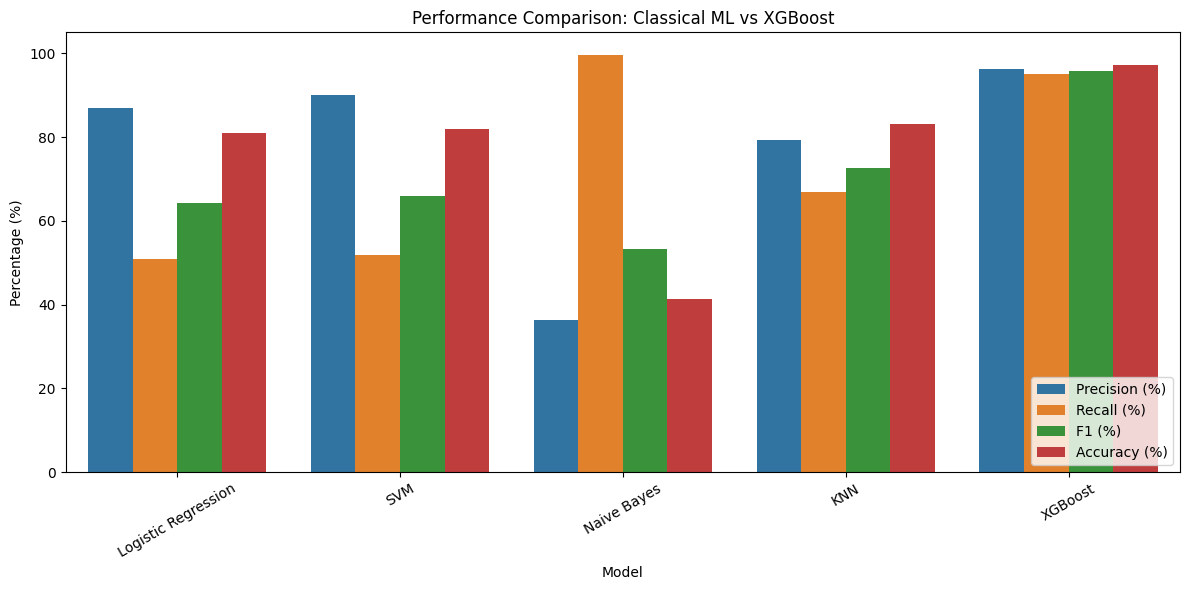

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only selected models for comparison
selected_models = ['Logistic Regression', 'SVM', 'Naive Bayes', 'KNN', 'XGBoost']
plot_df = results_df.loc[selected_models].reset_index()

# Melt dataframe for seaborn
melted_df = plot_df.melt(id_vars='Model',
                         value_vars=['Precision (%)', 'Recall (%)', 'F1 (%)', 'Accuracy (%)'],
                         var_name='Metric', value_name='Score')

plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_df)
plt.ylim(0, 105)
plt.title("Performance Comparison: Classical ML vs XGBoost")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



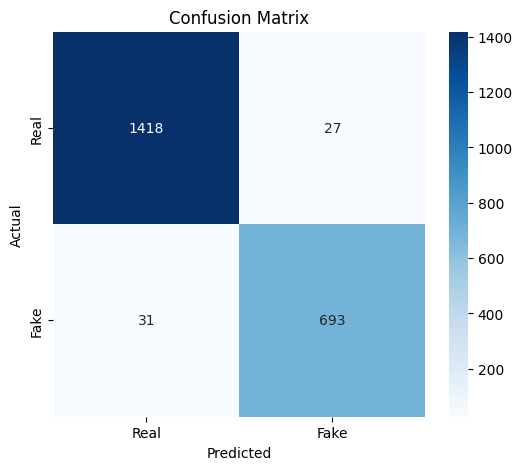

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



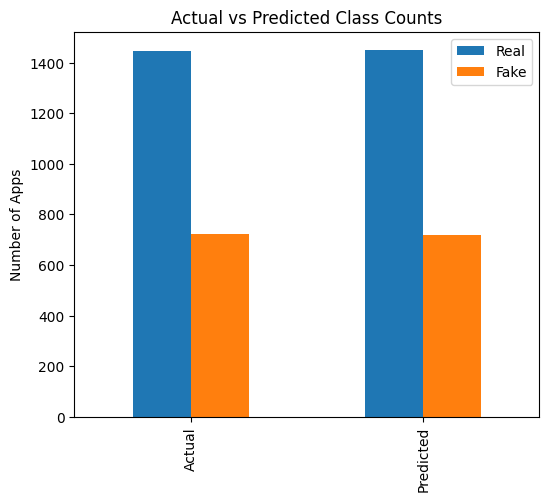

In [ ]:
import pandas as pd

# True vs Predicted counts
df_viz = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
counts = pd.DataFrame({
    'Actual': df_viz['Actual'].value_counts(),
    'Predicted': df_viz['Predicted'].value_counts()
}).T

counts.columns = ['Real', 'Fake']

counts.plot(kind='bar', figsize=(6,5))
plt.title('Actual vs Predicted Class Counts')
plt.ylabel('Number of Apps')
plt.show()


<Figure size 800x600 with 0 Axes>

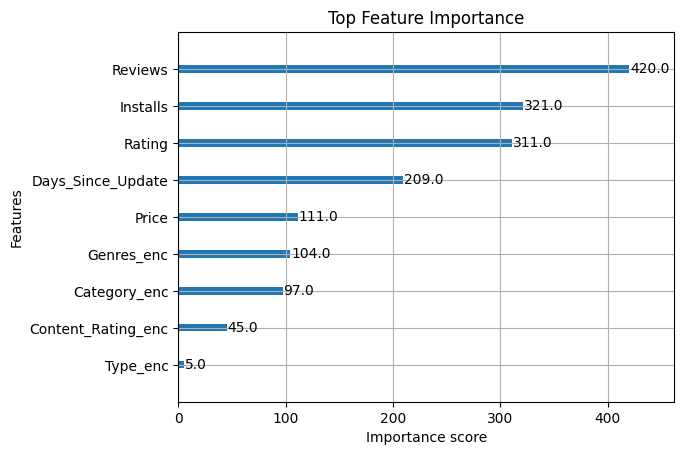

In [ ]:
from xgboost import plot_importance

plt.figure(figsize=(8,6))
plot_importance(xgb, max_num_features=10, importance_type='weight', title='Top Feature Importance')
plt.show()


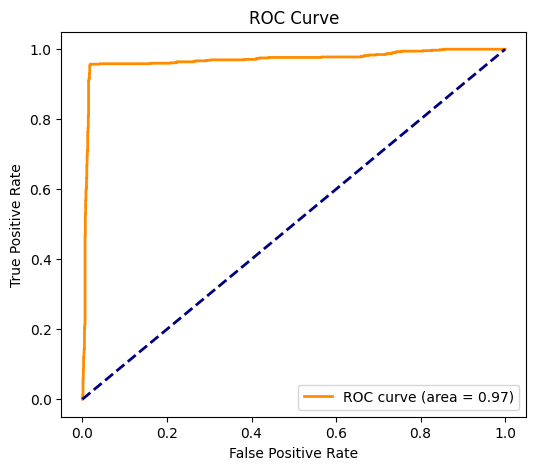

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = xgb.predict_proba(X_test)[:,1]  # probability of Fake
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
